In [ ]:
!python -c "import torch; print(torch.__version__)"

2.5.1+cu121


In [1]:
%%capture
%env TORCH=2.5.1+cu121
!pip install torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install torch-geometric

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as tnn
from torch_geometric.utils import from_networkx
from torch_geometric import nn
from scipy.stats import norm

In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [4]:
def randomGraphWithCorrs(n,m,d=64,correlate=False,rescale=False):  # BA Model graphs - n nodes, m edges each iter, d dim. feats, can be correlated
  G = nx.complete_graph(m)
  feats = np.random.rand(n,d)  # Unif. U[0,1] values
  for i in range(n-m):
    nodes, degs = np.array(list(zip(*G.degree)))
    degs = degs / np.sum(degs)   #  Normalise
    conns = np.random.choice(nodes,m,replace=False,p=degs)  # Connecting nodes
    G.add_node(m+i)
    G.add_edges_from([(conn,m+i) for conn in conns])

    if correlate:
      probs = degs[np.where(np.in1d(nodes,conns))]  # Extract prob's that actually occurred, use these as correlations
      if rescale:
        probs = probs / np.sum(probs)

      probs = (np.pi / 6) * probs   # Convert unif. corr. to desired norm. corr.
      probs = 2 * np.sin(probs)
      featVals = feats[conns]   # m x d feature matrix
      featVals = norm.ppf(featVals)   # Convert unif. dist. to norm. dist.
      meanVec = np.dot(probs,featVals)
      varVal = 1 - np.dot(probs,probs)
      varMat = varVal * np.identity(d)
      newFeat = np.random.multivariate_normal(meanVec,varMat)
      newFeat = norm.cdf(newFeat)   # Convert norm. dist. to unif. dist.
      feats[m+i] = newFeat

  H = from_networkx(G)
  H.x = torch.from_numpy(feats).float()
  return H

In [5]:
def runExperiment(model, graphType, corrScheme, N, c):
  # Specify model (GCN or GAT), graph type (Dense or Sparse), correlation scheme (None, Simple, Rescaled), list of graph sizes N and no. of classes c
  d = 32   # Hidden dim. for feats
  s = 30   # No. of repeats for each graph size
  if model == "GCN":
    model1 = nn.models.GCN(in_channels=d,hidden_channels=d,num_layers=3).to(device)
  elif model == "GAT":
    model1 = nn.models.GAT(in_channels=d,hidden_channels=d,num_layers=3).to(device)
  lin1 = tnn.Linear(d,c).to(device)
  meanDists = torch.zeros((len(N),c)).to(device)   # Mean output, for each graph size
  stdevDists = torch.zeros((len(N),c)).to(device)   # Standard deviation output, for each graph size
  for j in range(len(N)):
    n = N[j]
    outDists = torch.rand((s,c)).to(device)   # Used to find mean and stdev output
    for i in range(s):
      with torch.no_grad():
        if graphType == "Dense":
          m = n // 5
        elif graphType == "Sparse":
          m = 5

        if corrScheme == "None":
          G = randomGraphWithCorrs(n,m,d)
        elif corrScheme == "Simple":
          G = randomGraphWithCorrs(n,m,d,correlate=True)
        elif corrScheme == "Rescaled":
          G = randomGraphWithCorrs(n,m,d,correlate=True,rescale=True)

        G = G.to(device)
        nodeFeats = model1(G.x,G.edge_index)
        graphVec = torch.mean(nodeFeats,dim=0)   # Mean pooling
        graphVec = lin1(graphVec)   # Single-layer MLP

        outDist = tnn.Softmax(dim=0)(graphVec)
        outDists[i] = outDist

    meanDist = torch.mean(outDists,dim=0)
    stdevDist = torch.std(outDists,dim=0)

    meanDists[j] = meanDist
    stdevDists[j] = stdevDist

    print("Size:",n,"Mean:",meanDist,"St. dev.:",stdevDist)


  meanDists = meanDists.detach().cpu().numpy()
  stdevDists = stdevDists.detach().cpu().numpy()

  return meanDists, stdevDists

Size: 25 Mean: tensor([0.2815, 0.3961, 0.3225]) St. dev.: tensor([0.0041, 0.0019, 0.0035])
Size: 50 Mean: tensor([0.2808, 0.3969, 0.3223]) St. dev.: tensor([0.0027, 0.0018, 0.0023])
Size: 75 Mean: tensor([0.2821, 0.3966, 0.3213]) St. dev.: tensor([0.0022, 0.0013, 0.0016])
Size: 100 Mean: tensor([0.2816, 0.3966, 0.3218]) St. dev.: tensor([0.0020, 0.0013, 0.0016])
Size: 250 Mean: tensor([0.2820, 0.3965, 0.3215]) St. dev.: tensor([0.0011, 0.0008, 0.0010])
Size: 500 Mean: tensor([0.2822, 0.3964, 0.3214]) St. dev.: tensor([0.0009, 0.0006, 0.0006])
Size: 750 Mean: tensor([0.2825, 0.3963, 0.3213]) St. dev.: tensor([0.0008, 0.0005, 0.0006])
Size: 1000 Mean: tensor([0.2825, 0.3962, 0.3212]) St. dev.: tensor([0.0005, 0.0003, 0.0004])
Size: 1500 Mean: tensor([0.2825, 0.3964, 0.3212]) St. dev.: tensor([0.0005, 0.0003, 0.0004])
Size: 2000 Mean: tensor([0.2826, 0.3961, 0.3213]) St. dev.: tensor([0.0005, 0.0003, 0.0004])
Size: 25 Mean: tensor([0.2937, 0.3346, 0.3717]) St. dev.: tensor([0.0039, 0.0051

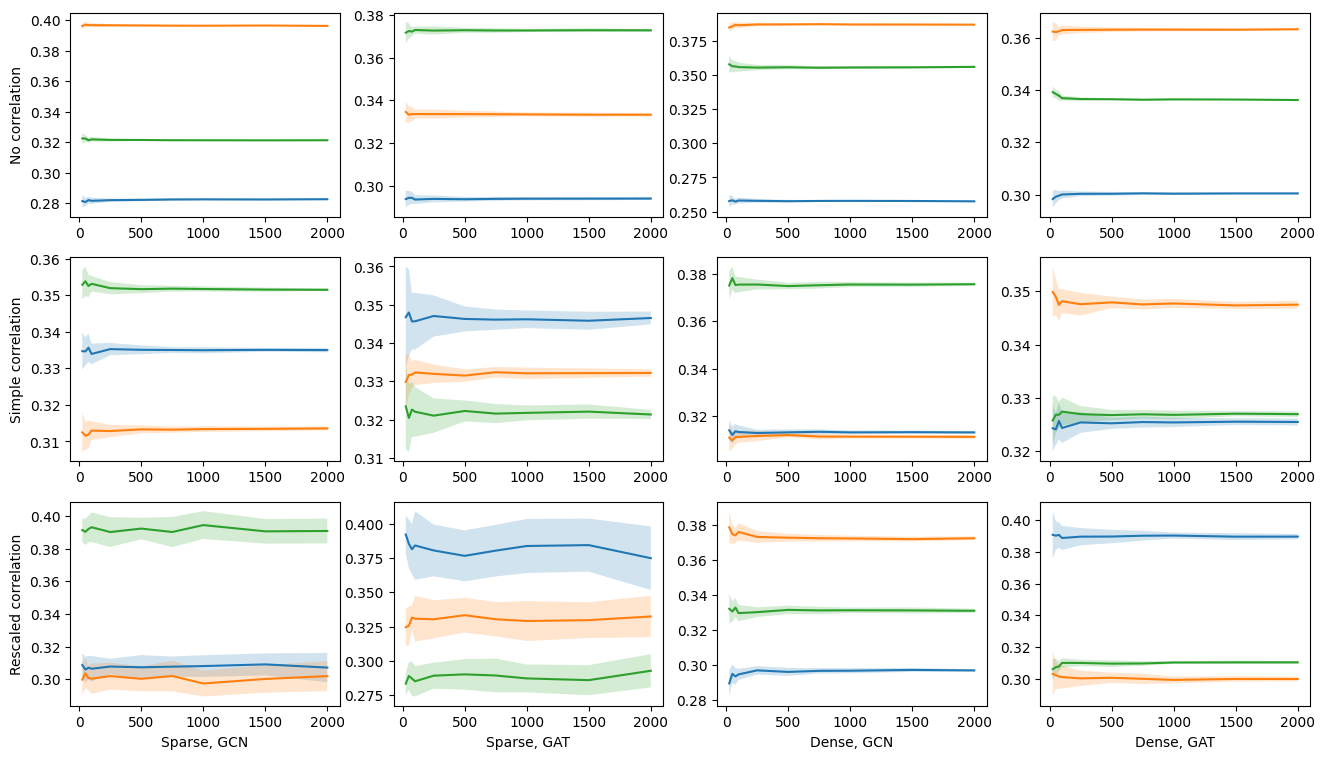

In [6]:
c = 3   # No. of classes for graph classification
N = [25,50,75,100,250,500,750,1000,1500,2000]   # Graph sizes used

fig, axs = plt.subplots(3, 4, figsize=(16,9))

meanDists, stdevDists = runExperiment("GCN","Sparse","None",N,c)
axs[0,0].set_ylabel("No correlation")
for colInd in range(c):
  axs[0,0].plot(N,meanDists[:,colInd])
  axs[0,0].fill_between(N, meanDists[:,colInd] - stdevDists[:,colInd], meanDists[:,colInd] + stdevDists[:,colInd], alpha = 0.2)

meanDists, stdevDists = runExperiment("GAT","Sparse","None",N,c)
for colInd in range(c):
  axs[0,1].plot(N,meanDists[:,colInd])
  axs[0,1].fill_between(N, meanDists[:,colInd] - stdevDists[:,colInd], meanDists[:,colInd] + stdevDists[:,colInd], alpha = 0.2)

meanDists, stdevDists = runExperiment("GCN","Dense","None",N,c)
for colInd in range(c):
  axs[0,2].plot(N,meanDists[:,colInd])
  axs[0,2].fill_between(N, meanDists[:,colInd] - stdevDists[:,colInd], meanDists[:,colInd] + stdevDists[:,colInd], alpha = 0.2)

meanDists, stdevDists = runExperiment("GAT","Dense","None",N,c)
for colInd in range(c):
  axs[0,3].plot(N,meanDists[:,colInd])
  axs[0,3].fill_between(N, meanDists[:,colInd] - stdevDists[:,colInd], meanDists[:,colInd] + stdevDists[:,colInd], alpha = 0.2)

meanDists, stdevDists = runExperiment("GCN","Sparse","Simple",N,c)
axs[1,0].set_ylabel("Simple correlation")
for colInd in range(c):
  axs[1,0].plot(N,meanDists[:,colInd])
  axs[1,0].fill_between(N, meanDists[:,colInd] - stdevDists[:,colInd], meanDists[:,colInd] + stdevDists[:,colInd], alpha = 0.2)

meanDists, stdevDists = runExperiment("GAT","Sparse","Simple",N,c)
for colInd in range(c):
  axs[1,1].plot(N,meanDists[:,colInd])
  axs[1,1].fill_between(N, meanDists[:,colInd] - stdevDists[:,colInd], meanDists[:,colInd] + stdevDists[:,colInd], alpha = 0.2)

meanDists, stdevDists = runExperiment("GCN","Dense","Simple",N,c)
for colInd in range(c):
  axs[1,2].plot(N,meanDists[:,colInd])
  axs[1,2].fill_between(N, meanDists[:,colInd] - stdevDists[:,colInd], meanDists[:,colInd] + stdevDists[:,colInd], alpha = 0.2)

meanDists, stdevDists = runExperiment("GAT","Dense","Simple",N,c)
for colInd in range(c):
  axs[1,3].plot(N,meanDists[:,colInd])
  axs[1,3].fill_between(N, meanDists[:,colInd] - stdevDists[:,colInd], meanDists[:,colInd] + stdevDists[:,colInd], alpha = 0.2)

meanDists, stdevDists = runExperiment("GCN","Sparse","Rescaled",N,c)
axs[2,0].set_ylabel("Rescaled correlation")
axs[2,0].set_xlabel("Sparse, GCN")
for colInd in range(c):
  axs[2,0].plot(N,meanDists[:,colInd])
  axs[2,0].fill_between(N, meanDists[:,colInd] - stdevDists[:,colInd], meanDists[:,colInd] + stdevDists[:,colInd], alpha = 0.2)

meanDists, stdevDists = runExperiment("GAT","Sparse","Rescaled",N,c)
axs[2,1].set_xlabel("Sparse, GAT")
for colInd in range(c):
  axs[2,1].plot(N,meanDists[:,colInd])
  axs[2,1].fill_between(N, meanDists[:,colInd] - stdevDists[:,colInd], meanDists[:,colInd] + stdevDists[:,colInd], alpha = 0.2)

meanDists, stdevDists = runExperiment("GCN","Dense","Rescaled",N,c)
axs[2,2].set_xlabel("Dense, GCN")
for colInd in range(c):
  axs[2,2].plot(N,meanDists[:,colInd])
  axs[2,2].fill_between(N, meanDists[:,colInd] - stdevDists[:,colInd], meanDists[:,colInd] + stdevDists[:,colInd], alpha = 0.2)

meanDists, stdevDists = runExperiment("GAT","Dense","Rescaled",N,c)
axs[2,3].set_xlabel("Dense, GAT")
for colInd in range(c):
  axs[2,3].plot(N,meanDists[:,colInd])
  axs[2,3].fill_between(N, meanDists[:,colInd] - stdevDists[:,colInd], meanDists[:,colInd] + stdevDists[:,colInd], alpha = 0.2)


plt.savefig("GRLConvergences.png")
plt.show()

In [ ]:
''' Below, we also test to see if our equation for sum of correlations matches observations in asymptoticity. '''

In [7]:
def randomGraphWithCorrsTest(n,m):  # BA model graphs - n nodes, m edges each iter, use this to examine correlations in final iteration
  G = nx.complete_graph(m)
  out = 0
  for i in range(n-m):
    nodes, degs = np.array(list(zip(*G.degree)))
    degs = degs / np.sum(degs)   #  Normalise
    conns = np.random.choice(nodes,m,replace=False,p=degs)   # Connecting nodes
    G.add_node(m+i)
    G.add_edges_from([(conn,m+i) for conn in conns])

    probs = degs[np.where(np.in1d(nodes,conns))]  # Extract prob's that actually occurred, use these as correlations
    if i == n-m-1:   # Store correlations from final iteration
      out = probs

  return np.sum(out)    # Output corr. sum from final iter.

25 0.24492063492063493
50 0.1376086956521739
75 0.08661971830985916
100 0.07826388888888888
250 0.03981029810298103
500 0.019516129032258064
750 0.013025022341376232
1000 0.010873493975903615
1500 0.007132352941176471
2000 0.0050784903139612534


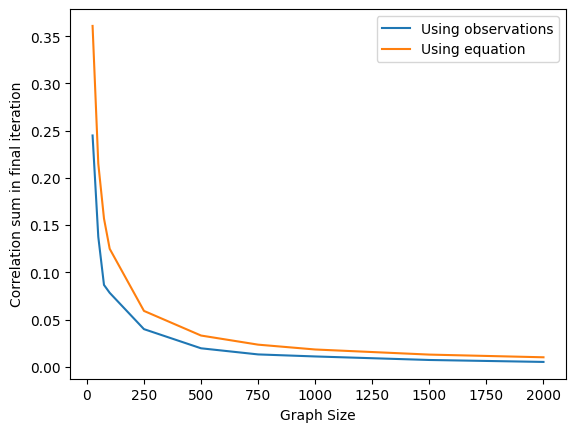

In [8]:
s = 30   # No. of repeats for each graph size
m = 5   # No. of edges added each iter. in BA model
obsCorrs = []    # Observed final iter. correlation sum, for each graph size
N = [25,50,75,100,250,500,750,1000,1500,2000]    # Graph sizes used
for n in N:
  corrTot = 0    # Take mean of correlation sums over s samples
  for i in range(s):
    corrSum = randomGraphWithCorrsTest(n,m)
    corrTot = corrTot + corrSum

  corrTot = corrTot / s
  print(n, corrTot)
  obsCorrs.append(corrTot)

f = lambda m,n : (m * (2 + np.log(n / m)) / (2*n))
eqnCorrs = [f(m,n) for n in N]   # Apply equation to generate anticipated final iter. correlation sum, for each graph size
fig = plt.figure()
ax1 = fig.add_subplot(111)
ax1.set_xlabel("Graph Size")
ax1.set_ylabel("Correlation sum in final iteration")
ax1.plot(N,obsCorrs)
ax1.plot(N,eqnCorrs)
ax1.legend(["Using observations","Using equation"])
plt.savefig("GRLCorrSums.png")
plt.show()
